In [1]:
import numpy as np
import pandas as pd
import joblib

In [13]:
import pyspark.sql.functions as f
from pyspark.sql import SparkSession, Window
from pyspark import SparkConf

In [3]:
parameters = {
    "spark.driver.maxResultSize": "3g",
    "spark.hadoop.fs.s3a.impl": "org.apache.hadoop.fs.s3a.S3AFileSystem",
    "spark.sql.execution.arrow.pyspark.enabled": True,

    # https://docs.kedro.org/en/stable/integrations/pyspark_integration.html#tips-for-maximising-concurrency-using-threadrunner
    "spark.scheduler.mode": "FAIR",
    "spark.driver.extraJavaOptions": "-Djava.security.manager=allow",
    "spark.executor.extraJavaOptions": "-Djava.security.manager=allow",

    "spark.sql.legacy.parquet.nanosAsLong": True,
    "spark.driver.memory": "40g",
}

spark_conf = SparkConf().setAll(parameters.items())
spark = SparkSession.builder.appName('New').enableHiveSupport().config(conf=spark_conf).getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/05/07 18:13:46 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
ftr_transactions = spark.read.parquet("../data/04_feature/ftr_transactions")

In [5]:
ftr_transactions.columns

['_id',
 '_observ_end_dt',
 'month_total_sales',
 'month_net_sales',
 'month_total_profit',
 'month_total_cost',
 'month_total_amount_discounts',
 'month_total_qty_discounts',
 'month_distinct_skus_sold',
 'month_distinct_branches',
 'month_distinct_product_categories',
 'month_distinct_transactions',
 'month_avg_order',
 'month_avg_skus_per_order',
 'month_net_sales_category_ac',
 'month_total_profit_category_ac',
 'month_total_cost_category_ac',
 'month_total_amount_discounts_category_ac',
 'month_total_qty_discounts_category_ac',
 'month_net_sales_category_additives',
 'month_total_profit_category_additives',
 'month_total_cost_category_additives',
 'month_total_amount_discounts_category_additives',
 'month_total_qty_discounts_category_additives',
 'month_net_sales_category_air_filter',
 'month_total_profit_category_air_filter',
 'month_total_cost_category_air_filter',
 'month_total_amount_discounts_category_air_filter',
 'month_total_qty_discounts_category_air_filter',
 'month_net_

In [18]:
w_churn_acc = Window.partitionBy("_id").orderBy(f.col("_observ_end_dt")).rowsBetween(-2, 0)

win_id_monthly = Window.partitionBy("_id").orderBy(f.col("_observ_end_dt"))

In [25]:
ftr_transactions = ftr_transactions.withColumn(
    "days_until_mineral_oil_change",
    f.col("estimated_days_to_change_mineral_oil") - f.col("days_since_last_transactions")
).withColumn(
    "days_until_synthetic_oil_change",
    f.col("estimated_days_to_change_synthetic_oil") - f.col("days_since_last_transactions")
).withColumn(
    "below_estimated_mineral_oil_change",
    (f.col("days_until_mineral_oil_change") > 0).cast("int")
).withColumn(
    "below_estimated_synthetic_oil_change",
    (f.col("days_until_synthetic_oil_change") > 0).cast("int")
).withColumn(
    "customer_mineral_oil",
    f.when(
        f.col("month_net_sales_category_oil") > 0,
        1
    ).otherwise(None)
).withColumn(
    "customer_synthetic_oil",
    f.when(
        f.col("month_net_sales_category_oil_synthetic") > 0,
        1
    ).otherwise(None)
).withColumn(
    "customer_mineral_oil",
    f.last("customer_mineral_oil", ignorenulls=True).over(win_id_monthly.rangeBetween(Window.unboundedPreceding, 0))
).withColumn(
    "customer_synthetic_oil",
    f.last("customer_synthetic_oil", ignorenulls=True).over(win_id_monthly.rangeBetween(Window.unboundedPreceding, 0))
).withColumn(
    "customer_mineral_oil",
    f.when(
        f.col("customer_mineral_oil").isNull(),
        0
    ).otherwise(f.col("customer_mineral_oil"))
).withColumn(
    "customer_synthetic_oil",
    f.when(
        f.col("customer_synthetic_oil").isNull(),
        0
    ).otherwise(f.col("customer_synthetic_oil"))
).withColumn(
    "is_churn",
    f.when(
        (f.col("is_active") > 0),
        0
    ).when(
        (f.col("customer_mineral_oil") > 0) &
        (f.col("below_estimated_mineral_oil_change") > 0),
        0
    ).when(
        (f.col("customer_synthetic_oil") > 0) &
        (f.col("below_estimated_synthetic_oil_change") > 0),
        0
    ).otherwise(1)
).withColumn(
    "is_churn_30",
    f.when(
        (f.col("is_active") > 0),
        0
    ).when(
        (f.col("customer_mineral_oil") > 0) &
        (f.col("days_until_mineral_oil_change") < 30),
        0
    ).when(
        (f.col("customer_synthetic_oil") > 0) &
        (f.col("days_until_synthetic_oil_change") < 30),
        0
    ).otherwise(1)
).withColumn(
    "is_churn_60",
    f.when(
        (f.col("is_active") > 0),
        0
    ).when(
        (f.col("customer_mineral_oil") > 0) &
        (f.col("days_until_mineral_oil_change") < 60),
        0
    ).when(
        (f.col("customer_synthetic_oil") > 0) &
        (f.col("days_until_synthetic_oil_change") < 60),
        0
    ).otherwise(1)
).withColumn(
    "target_churn_1",
    f.max("is_churn").over(win_id_monthly.rowsBetween(1, 1))
).withColumn(
    "target_churn_2",
    f.max("is_churn").over(win_id_monthly.rowsBetween(2, 2))
).withColumn(
    "target_churn_3",
    f.max("is_churn").over(win_id_monthly.rowsBetween(3, 3))
).withColumn(
    "acc_churn_past_2_next_0_months",
    f.sum("is_churn").over(w_churn_acc)
)

In [26]:
ftr_transactions.filter(
    f.col("is_active") > 0
).filter(
    f.col("_observ_end_dt") >= "2021-01-01"
).filter(
    f.col("_observ_end_dt") < "2024-01-01"
).groupBy(
    "_observ_end_dt"
).agg(
    f.countDistinct("_id").alias("# of clients"),
    f.sum("customer_mineral_oil").alias("# of mineral oil clients"),
    f.sum("customer_synthetic_oil").alias("# of synthetic oil clients"),
).orderBy(
    "_observ_end_dt"
).show()

+--------------+------------+------------------------+--------------------------+
|_observ_end_dt|# of clients|# of mineral oil clients|# of synthetic oil clients|
+--------------+------------+------------------------+--------------------------+
|    2021-01-31|      258787|                  173476|                     84766|
|    2021-02-28|      223925|                  150981|                     73196|
|    2021-03-31|      262208|                  176877|                     86609|
|    2021-04-30|      235781|                  159294|                     78148|
|    2021-05-31|      289906|                  195006|                     99062|
|    2021-06-30|      265862|                  173911|                     95122|
|    2021-07-31|      286124|                  189636|                    100888|
|    2021-08-31|      288960|                  192054|                    101731|
|    2021-09-30|      341952|                  241378|                    112854|
|    2021-10-31|

In [27]:
ftr_transactions.filter(
    # f.col("is_active") > 0
    f.lit(True) == True
).filter(
    f.col("acc_churn_past_2_next_0_months") < 2
    # f.lit(True) == True
).filter(
    f.col("_observ_end_dt") >= "2021-01-01"
).filter(
    f.col("_observ_end_dt") < "2024-01-01"
).groupBy(
    "_observ_end_dt"
).agg(
    f.mean("target_churn_1").alias("target_1_pos"),
    f.mean("target_churn_2").alias("target_2_pos"),
    f.mean("target_churn_3").alias("target_3_pos"),
).orderBy("_observ_end_dt").show(50, truncate=False)

25/05/07 18:35:30 WARN Column: Constructing trivially true equals predicate, 'true = true'. Perhaps you need to use aliases.


+--------------+-------------------+-------------------+-------------------+
|_observ_end_dt|target_1_pos       |target_2_pos       |target_3_pos       |
+--------------+-------------------+-------------------+-------------------+
|2021-01-31    |0.48639221833899526|0.5446970675623305 |0.5981191758869061 |
|2021-02-28    |0.46010763235133845|0.5364499362999876 |0.5513452164860894 |
|2021-03-31    |0.45861352667235233|0.5014140418494781 |0.5367025198630044 |
|2021-04-30    |0.43261535027582027|0.49135271515576673|0.5213740792704314 |
|2021-05-31    |0.42534586372030425|0.479764624870888  |0.5134296065604558 |
|2021-06-30    |0.42016137276800786|0.47717422125005066|0.4970979520742554 |
|2021-07-31    |0.41567792294023775|0.45974791279186017|0.5152640653117891 |
|2021-08-31    |0.4000387053794895 |0.4781063393084763 |0.5196699622064299 |
|2021-09-30    |0.41189752209056607|0.5030128254304783 |0.5486567819955784 |
|2021-10-31    |0.43690869895613943|0.5035754837132599 |0.5433176450165533 |

In [7]:
ftr_transactions.filter(
    f.col("is_active") > 0
).filter(
    f.col("month_avg_mileage_per_day") < 101
    # f.lit(True) == True
).filter(
    f.col("_observ_end_dt") >= "2021-01-01"
).filter(
    f.col("_observ_end_dt") < "2024-01-01"
).show(5, truncate=False)

25/05/07 18:14:13 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------------------------------------------------------------------------+--------------+------------------+------------------+------------------+------------------+----------------------------+-------------------------+------------------------+-----------------------+---------------------------------+---------------------------+------------------+------------------------+---------------------------+------------------------------+----------------------------+----------------------------------------+-------------------------------------+----------------------------------+-------------------------------------+-----------------------------------+-----------------------------------------------+--------------------------------------------+-----------------------------------+--------------------------------------+------------------------------------+------------------------------------------------+---------------------------------------------+----------------------------------+------------

In [8]:
working_ids = [
    "A4F50776-4238-465E-AE0D-1C8C376CAEE2__37D422A0-E176-4D4F-8721-3B231E1ABAA0",
    "A4F507F5-769F-4C5E-9D3A-CBDD668AB6C8__4124CB72-D524-4A5E-8806-2D741083C98A",
    "A4F508D3-F915-4881-92E1-64E425B7FA71__DE8981C4-D7CF-46AC-8E18-5A844E1B5F7F",
    "A4F510D7-F015-432A-ABCB-E72594B42014__BD2B7690-017A-4437-9F8C-85518A3CF131",
    "A4F51822-9DBE-4CEF-834F-F5BC2DC179EC__B089C48B-85D1-4E8C-BBFC-33BEA68D5027",
    "A4F52279-0F64-4165-BB89-600CD3314D59__4D5A9841-55D7-492F-B695-78DE31B6A760", ## GOOD ID
    "A4F553E8-D26B-4BB7-90E3-75D3F2950064__D71989F6-16FF-48D5-919B-4BA2286EF08D", ## GOOD ID
]

In [21]:
ftr_transactions.filter(
    # f.col("is_active") > 0
    f.col("_id") == working_ids[6]
).filter(
    # f.col("acc_churn_past_2_next_0_months") < 2
    f.lit(True) == True
).filter(
    f.col("_observ_end_dt") >= "2021-01-01"
).filter(
    f.col("_observ_end_dt") < "2024-01-01"
).select("_id", "_observ_end_dt", "is_active", "customer_mineral_oil", "customer_synthetic_oil", "last_trx_total_sales", "month_total_sales", "last_trx_current_mileage", "month_avg_mileage_per_day", "month_avg_mileage_per_day_max_past_5_next_0_months", "month_avg_mileage_per_day_nullif_past_11_next_0_months", "below_estimated_mineral_oil_change", "below_estimated_synthetic_oil_change", "is_churn", "target_churn_1", "acc_churn_past_2_next_0_months").orderBy("_id", "_observ_end_dt").show(30, truncate=False)

25/05/07 18:26:05 WARN Column: Constructing trivially true equals predicate, 'true = true'. Perhaps you need to use aliases.


+--------------------------------------------------------------------------+--------------+---------+--------------------+----------------------+--------------------+-----------------+------------------------+-------------------------+--------------------------------------------------+------------------------------------------------------+----------------------------------+------------------------------------+--------+--------------+------------------------------+
|_id                                                                       |_observ_end_dt|is_active|customer_mineral_oil|customer_synthetic_oil|last_trx_total_sales|month_total_sales|last_trx_current_mileage|month_avg_mileage_per_day|month_avg_mileage_per_day_max_past_5_next_0_months|month_avg_mileage_per_day_nullif_past_11_next_0_months|below_estimated_mineral_oil_change|below_estimated_synthetic_oil_change|is_churn|target_churn_1|acc_churn_past_2_next_0_months|
+-------------------------------------------------------------

# read models

In [2]:
mdl_churn_avg_metrics = joblib.load("../data/06_models/churn/model/mdl_churn_avg_metrics.pkl")
mdl_churn_metrics_df = pd.read_parquet("../data/06_models/churn/model/mdl_churn_metrics_df")
mdl_selected_features = joblib.load("../data/06_models/churn/model/selected_features.pkl")

In [3]:
mdl_churn_avg_metrics

{'precision': 0.5604196084871604,
 'recall': 0.837751122266895,
 'roc_auc': 0.8740982762339625,
 'pr_auc': 0.7340262328258479,
 'ks': 0.5690615299703888,
 'tp': 87669.2,
 'tn': 186530.8,
 'fp': 68771.2,
 'fn': 16977.8}

In [4]:
mdl_churn_metrics_df

,iteration,train_period,test_period,precision,recall,roc_auc,pr_auc,ks,ks-pvalue,tp,tn,fp,fn
0,1,2021-01-31/2023-08-31,2023-12-31/2023-12-31,0.563613,0.833103,0.874946,0.734744,0.569120,0.0,86886,187064,67273,17406
1,2,2021-01-31/2023-07-31,2023-11-30/2023-11-30,0.558701,0.834262,0.872542,0.730902,0.565672,0.0,87107,187126,68803,17305
2,3,2021-01-31/2023-06-30,2023-10-31/2023-10-31,0.560085,0.837843,0.875528,0.736623,0.571019,0.0,87599,188228,68804,16954
3,4,2021-01-31/2023-05-31,2023-09-30/2023-09-30,0.563089,0.841362,0.875769,0.737777,0.573922,0.0,88253,186437,68477,16640
4,5,2021-01-31/2023-04-30,2023-08-31/2023-08-31,0.556610,0.842185,0.871706,0.730085,0.565574,0.0,88501,183799,70499,16584


In [5]:
mdl_churn_metrics_df.drop(columns=["train_period", "test_period"]).mean()

iteration         3.000000
precision         0.560420
recall            0.837751
roc_auc           0.874098
pr_auc            0.734026
ks                0.569062
ks-pvalue         0.000000
tp            87669.200000
tn           186530.800000
fp            68771.200000
fn            16977.800000
dtype: float64

In [1]:
(239896.333333 + 96156.666667) / (239896.333333 + 213064.111111 + 92940.333333 + 96156.666667)

0.5234002080468213

In [9]:
239896.333333 + 213064.111111 + 92940.333333 + 96156.666667

642057.444444

In [10]:
239896 / 642057.444444, 213064 / 642057.444444, 92940 / 642057.444444, 96157 / 642057.444444

(0.37363634994956224,
 0.33184569674214465,
 0.1447534029925981,
 0.14976385809725903)

In [45]:
mdl_churn_predicted_df = pd.read_parquet("../data/07_model_output/churn/predict/mdl_churn_predicted")


In [46]:
mdl_churn_predicted_df["_observ_end_dt"].value_counts()

_observ_end_dt
2025-03-31    1168312
2025-02-28    1165946
2025-01-31    1165224
2025-04-30    1163123
Name: count, dtype: int64

In [47]:
mdl_churn_predicted_df_filtered = mdl_churn_predicted_df[["_id", "_observ_end_dt", "is_active", "last_transaction_dt", "churn_probability"]]
# mdl_churn_predicted_df_filtered[["customer_id", "customer_vehicle_id"]] = mdl_churn_predicted_df_filtered["_id"].str.split("__")
mdl_churn_predicted_df_filtered[["customer_id", "customer_vehicle_id"]] = mdl_churn_predicted_df_filtered["_id"].str.rpartition("__")[[0,2]]

/var/folders/3r/sqxygt_d4gs0bc8yhzxh19vw0000gp/T/ipykernel_9087/1069835505.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mdl_churn_predicted_df_filtered[["customer_id", "customer_vehicle_id"]] = mdl_churn_predicted_df_filtered["_id"].str.rpartition("__")[[0,2]]
/var/folders/3r/sqxygt_d4gs0bc8yhzxh19vw0000gp/T/ipykernel_9087/1069835505.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mdl_churn_predicted_df_filtered[["customer_id", "customer_vehicle_id"]] = mdl_churn_predicted_df_filtered["_id"].str.

In [48]:
mdl_churn_predicted_df_filtered.head(2)

,_id,_observ_end_dt,is_active,last_transaction_dt,churn_probability,customer_id,customer_vehicle_id
0,00000E2B-FD56-4F34-A54C-159E564F5F79__FF8A2477...,2025-01-31,0,NaT,0.932236,00000E2B-FD56-4F34-A54C-159E564F5F79,FF8A2477-4270-4547-B4CB-5706EA4479A0
1,00000E2B-FD56-4F34-A54C-159E564F5F79__FF8A2477...,2025-02-28,0,NaT,0.932236,00000E2B-FD56-4F34-A54C-159E564F5F79,FF8A2477-4270-4547-B4CB-5706EA4479A0


In [49]:
mdl_churn_predicted_df_filtered.shape

(4662605, 7)

In [50]:
customer_df = pd.read_parquet("../data/02_intermediate/int_customers")
vehicle_df = pd.read_parquet("../data/02_intermediate/int_vehicles")

In [51]:
customer_df.head(2)

,customer_id,creation_on,modified_on,user_title,customer_name,mobile,mobile2,email,gender,nationality,birth_date,location_name,is_owner,is_cash_customer,payterm,age,is_active,station_brand
0,EB5670AA-72D8-49CE-8FAC-00000859EB85,2021-03-12,2020-03-26,None,ABU RAKAN,0555551397,None,None,None,None,1900-01-01,None,True,True,None,NaN,True,PE
1,4C86E939-005E-4611-B4C1-00000A03F8CA,2021-03-12,2020-03-26,None,MR OLAYYAN,0547502121,None,None,None,None,1900-01-01,None,True,True,None,NaN,True,PE


In [52]:
vehicle_df.head(2)

,customer_vehicle_id,creation_on,modified_on,customer_id,maker,model,model_year,transmission_type,pms_name,plate_number,code_vin,is_driver_owner,station_brand,is_truck,vehicle_brand_level
0,918FE112-E062-4A56-8033-000001BFCEC6,2021-03-12,2020-03-26,40AA5E88-1966-4494-B3FE-54112BF3F479,CHEVROLET,SUBURBAN,2013.0,AUTOMATIC,None,5340AAJ,1GNSC8E07DR219313,False,PE,0,LOW
1,1B4AA1DD-1E18-4990-AB45-000002BF3307,2021-03-12,2020-03-26,E1EAFA23-0ADC-4AFA-A774-4E27CDA23AA9,LEXUS,LS400,1998.0,AUTOMATIC,TOYOTA,0068LAZ,JTB530F20W0115484,False,PE,0,HIGH


In [53]:
mdl_churn_predicted_df_extended = pd.merge(
    mdl_churn_predicted_df_filtered,
    customer_df[["customer_id", "customer_name", "mobile"]],
    on="customer_id",
)

# mdl_churn_predicted_df_extended.head()

In [54]:
mdl_churn_predicted_df_extended = pd.merge(
    mdl_churn_predicted_df_extended,
    vehicle_df[["customer_id", "customer_vehicle_id", "plate_number", "code_vin"]],
    on=["customer_id", "customer_vehicle_id"],
)
mdl_churn_predicted_df_extended.head(2)

,_id,_observ_end_dt,is_active,last_transaction_dt,churn_probability,customer_id,customer_vehicle_id,customer_name,mobile,plate_number,code_vin
0,00000E2B-FD56-4F34-A54C-159E564F5F79__FF8A2477...,2025-01-31,0,NaT,0.932236,00000E2B-FD56-4F34-A54C-159E564F5F79,FF8A2477-4270-4547-B4CB-5706EA4479A0,MOHAMAD,0548121618,2250ASR,KNAF241BEKA835999
1,00000E2B-FD56-4F34-A54C-159E564F5F79__FF8A2477...,2025-02-28,0,NaT,0.932236,00000E2B-FD56-4F34-A54C-159E564F5F79,FF8A2477-4270-4547-B4CB-5706EA4479A0,MOHAMAD,0548121618,2250ASR,KNAF241BEKA835999


In [55]:
mdl_churn_predicted_df_extended["_observ_end_dt"].value_counts()

_observ_end_dt
2025-03-31    1168312
2025-02-28    1165946
2025-01-31    1165224
2025-04-30    1163123
Name: count, dtype: int64

In [56]:
mdl_churn_predicted_df_extended["_observ_end_dt"] = pd.to_datetime(mdl_churn_predicted_df_extended["_observ_end_dt"], format="%Y-%m-%d")
mdl_churn_predicted_df_extended_202505 = mdl_churn_predicted_df_extended[mdl_churn_predicted_df_extended["_observ_end_dt"] == pd.to_datetime("2025-04-30", format="%Y-%m-%d")]
mdl_churn_predicted_df_extended_202505.shape

(1163123, 11)

In [57]:
customer_ago_df = pd.read_excel("202505_May_TargetList_MasterFile.xlsx", sheet_name="Sheet1")

In [58]:
customer_ago_df.head()

,LastPhoneDigit,Nationality,Segment,LastPromoTaken,IsPromoHunter,IsChinesePMS,is40Kmultiple,DueOil,DuePMS,DueAirFilter,...,InvoicePromoCounts_total,InvoiceCounts_total,Last visit date,Mobile,PlateNumber,Make,Model,PreferredLanguage,Wave 2 Promo,Group
0,7,Saudi,Uncommitted,Special Promo Service Mineral,1,0,NaN,1,0,0,...,3.0,16.0,NaN,966506246397,3006SVA,HONDA,ACCORD,AR,NaN,NaN
1,3,Others,New Joiner,Null,0,0,NaN,0,1,0,...,0.0,1.0,NaN,966506248223,4741ZKR,TOYOTA,RAV4,AR,Toyota PMS,NaN
2,4,Saudi,Potential Loyal,Null,0,0,NaN,1,0,0,...,1.0,5.0,NaN,966506248534,8945TZD,MAZDA,MAZDA CX-9,AR,NaN,NaN
3,7,Saudi,Uncommitted,Null,0,0,NaN,1,0,0,...,1.0,5.0,NaN,966506250247,4603RAA,TOYOTA,CAMRY,AR,NaN,NaN
4,3,Others,Potential Loyal,Null,0,0,38041.0,1,0,0,...,9.0,31.0,NaN,966506255293,8389EBD,TOYOTA,CAMRY,AR,NaN,NaN


In [59]:
customer_ago_df.shape # (421486, X31)

(421485, 31)

In [60]:
mdl_churn_predicted_df_extended.shape

(4662605, 11)

In [61]:
customer_ago_df["Mobile"] = customer_ago_df["Mobile"].astype("string")

In [62]:
mdl_churn_predicted_df_extended_202505["plate_number"] = mdl_churn_predicted_df_extended_202505["plate_number"].str.zfill(7)

/var/folders/3r/sqxygt_d4gs0bc8yhzxh19vw0000gp/T/ipykernel_9087/1323931722.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mdl_churn_predicted_df_extended_202505["plate_number"] = mdl_churn_predicted_df_extended_202505["plate_number"].str.zfill(7)


In [63]:
mdl_churn_predicted_df_extended_202505["mobile"] = mdl_churn_predicted_df_extended_202505["mobile"].str.zfill(10)
mdl_churn_predicted_df_extended_202505["mobile"] = mdl_churn_predicted_df_extended_202505["mobile"].str.slice_replace(stop=1, repl='966')

/var/folders/3r/sqxygt_d4gs0bc8yhzxh19vw0000gp/T/ipykernel_9087/943179947.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mdl_churn_predicted_df_extended_202505["mobile"] = mdl_churn_predicted_df_extended_202505["mobile"].str.zfill(10)
/var/folders/3r/sqxygt_d4gs0bc8yhzxh19vw0000gp/T/ipykernel_9087/943179947.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mdl_churn_predicted_df_extended_202505["mobile"] = mdl_churn_predicted_df_extended_202505["mobile"].str.slice_replace(stop=1, repl='966')


In [64]:
mdl_churn_predicted_df_extended_202505.shape, customer_ago_df.shape

((1163123, 11), (421485, 31))

In [65]:
mdl_churn_predicted_df_extended_202505 = mdl_churn_predicted_df_extended_202505.sort_values("churn_probability").drop_duplicates(subset=["mobile", "plate_number"], keep="last")

In [66]:
customer_ago_df.head(2)

,LastPhoneDigit,Nationality,Segment,LastPromoTaken,IsPromoHunter,IsChinesePMS,is40Kmultiple,DueOil,DuePMS,DueAirFilter,...,InvoicePromoCounts_total,InvoiceCounts_total,Last visit date,Mobile,PlateNumber,Make,Model,PreferredLanguage,Wave 2 Promo,Group
0,7,Saudi,Uncommitted,Special Promo Service Mineral,1,0,NaN,1,0,0,...,3.0,16.0,NaN,966506246397,3006SVA,HONDA,ACCORD,AR,NaN,NaN
1,3,Others,New Joiner,Null,0,0,NaN,0,1,0,...,0.0,1.0,NaN,966506248223,4741ZKR,TOYOTA,RAV4,AR,Toyota PMS,NaN


In [67]:
display(mdl_churn_predicted_df_extended_202505[mdl_churn_predicted_df_extended_202505["plate_number"] == "3006SVA"])
display(customer_ago_df[customer_ago_df["PlateNumber"] == "3006SVA"])

,_id,_observ_end_dt,is_active,last_transaction_dt,churn_probability,customer_id,customer_vehicle_id,customer_name,mobile,plate_number,code_vin
461587,1960DD01-EF6F-48F3-A6B7-6D2E5F2ACAB7__7F9A7F90...,2025-04-30,0,NaT,0.924765,1960DD01-EF6F-48F3-A6B7-6D2E5F2ACAB7,7F9A7F90-5503-4BA1-ADBF-702D04CC67F9,HASSAN,966506246397,3006SVA,JHMCM56597C400759


,LastPhoneDigit,Nationality,Segment,LastPromoTaken,IsPromoHunter,IsChinesePMS,is40Kmultiple,DueOil,DuePMS,DueAirFilter,...,InvoicePromoCounts_total,InvoiceCounts_total,Last visit date,Mobile,PlateNumber,Make,Model,PreferredLanguage,Wave 2 Promo,Group
0,7,Saudi,Uncommitted,Special Promo Service Mineral,1,0,NaN,1,0,0,...,3.0,16.0,NaN,966506246397,3006SVA,HONDA,ACCORD,AR,NaN,NaN


In [68]:
display(mdl_churn_predicted_df_extended_202505[mdl_churn_predicted_df_extended_202505["mobile"] == "96666506246397"])
display(customer_ago_df[customer_ago_df["Mobile"] == "96666506246397"])

,_id,_observ_end_dt,is_active,last_transaction_dt,churn_probability,customer_id,customer_vehicle_id,customer_name,mobile,plate_number,code_vin


,LastPhoneDigit,Nationality,Segment,LastPromoTaken,IsPromoHunter,IsChinesePMS,is40Kmultiple,DueOil,DuePMS,DueAirFilter,...,InvoicePromoCounts_total,InvoiceCounts_total,Last visit date,Mobile,PlateNumber,Make,Model,PreferredLanguage,Wave 2 Promo,Group


In [ ]:
mdl_churn_predicted_df_202505 = pd.merge(
    customer_ago_df.drop_duplicates(), #[["Mobile", "PlateNumber"]],
    mdl_churn_predicted_df_extended_202505[["_id", "churn_probability", "customer_name", "code_vin", "plate_number", "mobile"]],
    left_on=["PlateNumber", "Mobile"],
    right_on=["plate_number", "mobile"],
    how="left"
).drop(columns=["plate_number", "mobile"])


mdl_churn_predicted_df_202505.head(2)

,LastPhoneDigit,Nationality,Segment,LastPromoTaken,IsPromoHunter,IsChinesePMS,is40Kmultiple,DueOil,DuePMS,DueAirFilter,...,PlateNumber,Make,Model,PreferredLanguage,Wave 2 Promo,Group,_id,churn_probability,customer_name,code_vin
0,7,Saudi,Uncommitted,Special Promo Service Mineral,1,0,NaN,1,0,0,...,3006SVA,HONDA,ACCORD,AR,NaN,NaN,1960DD01-EF6F-48F3-A6B7-6D2E5F2ACAB7__7F9A7F90...,0.924765,HASSAN,JHMCM56597C400759
1,3,Others,New Joiner,Null,0,0,NaN,0,1,0,...,4741ZKR,TOYOTA,RAV4,AR,Toyota PMS,NaN,NaN,NaN,NaN,NaN


In [75]:
mdl_churn_predicted_df_202505[mdl_churn_predicted_df_202505["Last visit date"].isna()]["churn_probability"].isna().mean()

0.3771886553897435

In [76]:
mdl_churn_predicted_df_202505.groupby("DueOil").agg({"churn_probability": "mean"})

,churn_probability
DueOil,
0,0.840599
1,0.859093


<Axes: >

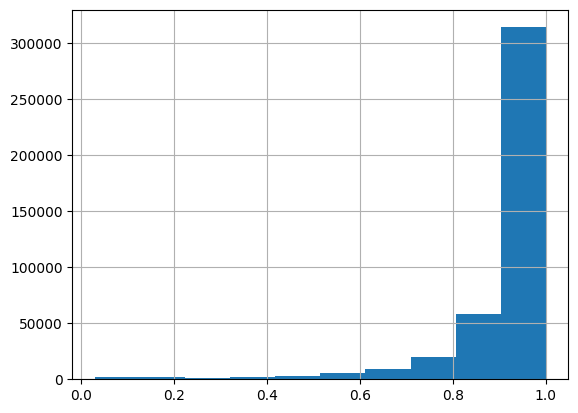

In [78]:
mdl_churn_predicted_df_202505["churn_probability"].fillna(1).hist()

In [73]:
mdl_churn_predicted_df_202505.shape

(417608, 35)

In [74]:
mdl_churn_predicted_df_202505.to_excel("202505_May_TargetList_MasterFile_Churn.xlsx", sheet_name="Churn", engine="openpyxl", index=False,)

In [117]:
filter_mobile = mdl_churn_predicted_df_extended_202505["plate_number"].isin(customer_ago_df["PlateNumber"].unique())
filter_dupe = mdl_churn_predicted_df_extended_202505["plate_number"].duplicated()

mdl_churn_predicted_df_extended_202505[filter_mobile & filter_dupe].head(5)

,_id,_observ_end_dt,is_active,last_transaction_dt,churn_probability,customer_id,customer_vehicle_id,customer_name,mobile,plate_number,code_vin
138354,029B16C1-22D5-4354-A29F-1F31769B76F2__63F784C8...,2025-04-30,0,NaT,0.864734,029B16C1-22D5-4354-A29F-1F31769B76F2,63F784C8-B118-4E95-B849-F5C365145E23,MOHAMMAD ALI,966580167985,5138JBR,KMHLN41E3NU298152
174392,034B19CE-AA7B-409D-B474-3EC9B81900F0__87A90C65...,2025-04-30,0,NaT,0.878040,034B19CE-AA7B-409D-B474-3EC9B81900F0,87A90C65-0A7B-4050-9269-5394B9CA2020,MR. ASHRAF,966533686370,8905VUB,1FM5K8B84DGA69607
189119,039446BE-0248-4D0C-AE16-DDC00C7FE51E__96883268...,2025-04-30,0,NaT,0.991764,039446BE-0248-4D0C-AE16-DDC00C7FE51E,96883268-703A-4CE8-B284-9F486EAC10F5,BADER,966545100629,4630LHB,RKLBV42E1D4470663
193646,03A9ACFE-0AEC-442B-9ABA-4ECFDE899BE3__52BEADD3...,2025-04-30,0,NaT,0.993509,03A9ACFE-0AEC-442B-9ABA-4ECFDE899BE3,52BEADD3-2D7A-4B64-A154-5AA93C3C14F4,MR. SULAIMAN,966569025199,9968EBB,KMHCM41A9BU499176
224717,043F858A-48B3-4D15-9636-1706F7515514__F03E9BA9...,2025-04-30,0,NaT,0.961158,043F858A-48B3-4D15-9636-1706F7515514,F03E9BA9-506D-4279-9167-A72A51CCAD32,ESSAM,966500074574,5008DND,JE4MR52N2KJ710310


In [118]:
filter_code = mdl_churn_predicted_df_extended_202505["plate_number"] == "5138JBR"

mdl_churn_predicted_df_extended_202505[filter_code]

,_id,_observ_end_dt,is_active,last_transaction_dt,churn_probability,customer_id,customer_vehicle_id,customer_name,mobile,plate_number,code_vin
51782,00FA2193-4651-4E4D-AF6E-FBBD6A6C136F__B91FA499...,2025-04-30,0,NaT,0.887650,00FA2193-4651-4E4D-AF6E-FBBD6A6C136F,B91FA499-7E27-46D7-B038-25D488E16552,AL WEFAQ,966580167985,5138JBR,KMHLN41E3NU298152
138354,029B16C1-22D5-4354-A29F-1F31769B76F2__63F784C8...,2025-04-30,0,NaT,0.864734,029B16C1-22D5-4354-A29F-1F31769B76F2,63F784C8-B118-4E95-B849-F5C365145E23,MOHAMMAD ALI,966580167985,5138JBR,KMHLN41E3NU298152
10511025,C718536F-379A-4B85-9203-519D22C1CFAF__06512B25...,2025-04-30,0,NaT,0.956655,C718536F-379A-4B85-9203-519D22C1CFAF,06512B25-92FD-478C-B9BB-F314B9C705DB,MR.MOHAMMAD ADLI,966580167985,5138JBR,KMHLN41E3NU298152


In [ ]:
mdl_churn_predicted_df_extended_202505.sort_values("churn_probability").drop_duplicates(subset=["mobile", "plate_number"], keep="last")

,_id,_observ_end_dt,is_active,last_transaction_dt,churn_probability,customer_id,customer_vehicle_id,customer_name,mobile,plate_number,code_vin
10511025,C718536F-379A-4B85-9203-519D22C1CFAF__06512B25...,2025-04-30,0,NaT,0.956655,C718536F-379A-4B85-9203-519D22C1CFAF,06512B25-92FD-478C-B9BB-F314B9C705DB,MR.MOHAMMAD ADLI,966580167985,5138JBR,KMHLN41E3NU298152


In [115]:
mdl_churn_predicted_df_extended_202505.duplicated().shape

(3434067,)

In [97]:
print("Mobile", customer_ago_df[["Mobile"]].drop_duplicates().shape)
print("PlateNumber", customer_ago_df[["PlateNumber"]].drop_duplicates().shape)
print("Both", customer_ago_df[["PlateNumber", "Mobile"]].drop_duplicates().shape)
print("None", customer_ago_df[["PlateNumber", "Mobile"]].shape)

Mobile (417608, 1)
PlateNumber (417039, 1)
Both (417608, 2)
None (421485, 2)


In [98]:
customer_ago_df.drop_duplicates().shape

(417608, 31)

In [94]:
mdl_churn_predicted_df_extended_202505[["plate_number", "mobile"]].drop_duplicates().shape

(3377392, 2)

In [72]:
filter = mdl_churn_predicted_df_extended["plate_number"].isin(["3006SVA"])
mdl_churn_predicted_df_extended[filter]

,_id,_observ_end_dt,is_active,last_transaction_dt,churn_probability,customer_id,customer_vehicle_id,customer_name,mobile,plate_number,code_vin
1342047,1960DD01-EF6F-48F3-A6B7-6D2E5F2ACAB7__7F9A7F90...,2025-01-31,1,2025-01-27 10:52:00,0.962400,1960DD01-EF6F-48F3-A6B7-6D2E5F2ACAB7,7F9A7F90-5503-4BA1-ADBF-702D04CC67F9,HASSAN,0506246397,3006SVA,JHMCM56597C400759
1342048,1960DD01-EF6F-48F3-A6B7-6D2E5F2ACAB7__7F9A7F90...,2025-02-28,0,NaT,0.968611,1960DD01-EF6F-48F3-A6B7-6D2E5F2ACAB7,7F9A7F90-5503-4BA1-ADBF-702D04CC67F9,HASSAN,0506246397,3006SVA,JHMCM56597C400759
1342049,1960DD01-EF6F-48F3-A6B7-6D2E5F2ACAB7__7F9A7F90...,2025-03-31,0,NaT,0.968611,1960DD01-EF6F-48F3-A6B7-6D2E5F2ACAB7,7F9A7F90-5503-4BA1-ADBF-702D04CC67F9,HASSAN,0506246397,3006SVA,JHMCM56597C400759
1342050,1960DD01-EF6F-48F3-A6B7-6D2E5F2ACAB7__7F9A7F90...,2025-04-30,0,NaT,0.964097,1960DD01-EF6F-48F3-A6B7-6D2E5F2ACAB7,7F9A7F90-5503-4BA1-ADBF-702D04CC67F9,HASSAN,0506246397,3006SVA,JHMCM56597C400759


In [57]:
mdl_churn_predicted_df[mdl_churn_predicted_df["_id"] == "1960DD01-EF6F-48F3-A6B7-6D2E5F2ACAB7__7F9A7F90-5503-4BA1-ADBF-702D04CC67F9"]

,_id,_observ_end_dt,month_total_sales,month_net_sales,month_total_profit,month_total_cost,month_total_amount_discounts,month_total_qty_discounts,month_distinct_skus_sold,month_distinct_branches,...,has_fuel_mean_past_11_next_0_months,has_fuel_mean_past_5_next_0_months,has_gear_mean_past_23_next_0_months,has_gear_mean_past_11_next_0_months,has_gear_mean_past_5_next_0_months,last_transaction_n_skus_mean_past_23_next_0_months,last_transaction_n_skus_mean_past_11_next_0_months,last_transaction_n_skus_mean_past_5_next_0_months,churn_probability,churn_prediction
93751,1960DD01-EF6F-48F3-A6B7-6D2E5F2ACAB7__7F9A7F90...,2025-01-31,135.580002,117.899998,75.370798,42.5292,84.699999,2,3,1,...,0.0,0.0,0.0,0.0,0.0,0.458333,0.25,0.5,0.9624,1


In [46]:
filter_mobile = mdl_churn_predicted_df_202505["PlateNumber"].isin(customer_ago_df["PlateNumber"].unique())
mdl_churn_predicted_df_202505[filter_mobile]

,_id,_observ_end_dt,is_active,last_transaction_dt,churn_probability,customer_id,customer_vehicle_id,customer_name,mobile,plate_number,...,InvoicePromoCounts_total,InvoiceCounts_total,Last visit date,Mobile,PlateNumber,Make,Model,PreferredLanguage,Wave 2 Promo,Group
0,00572597-D3BB-47F5-AC28-357007C495E6__261FAC3D...,2025-04-30,1,2025-04-10 14:32:47,0.977916,00572597-D3BB-47F5-AC28-357007C495E6,261FAC3D-B16A-4145-B7AB-4BF2CFDDC0A3,SAUD,0507077426,0411RUV,...,1.0,9.0,NaN,966561352293,0411RUV,TOYOTA,Aurion,EN,NaN,NaN
1,019C30E6-1371-48A9-89EB-592C9B8AC9A9__23EA6BBB...,2025-04-30,1,2025-04-14 17:54:23,0.480836,019C30E6-1371-48A9-89EB-592C9B8AC9A9,23EA6BBB-DAC1-47EA-9662-5B4F341168A6,AHMAD,0500979466,0075BGG,...,NaN,NaN,NaN,966500979495,0075BGG,LEXUS,LX570,AR,NaN,NaN
2,0390BD9D-3620-4765-9905-177C69BBB697__2EE6F5DD...,2025-04-30,1,2025-04-09 08:46:23,0.845278,0390BD9D-3620-4765-9905-177C69BBB697,2EE6F5DD-3E77-47AF-B761-6506D0A3522E,KHALID ALI,0505213042,0006TSJ,...,NaN,NaN,NaN,966553904940,0006TSJ,TOYOTA,AVALON,EN,NaN,UCG
3,046F4AD6-6CCD-4F33-A08E-CBD0EFEAF92B__1C912A34...,2025-04-30,1,2025-04-02 19:48:01,0.847068,046F4AD6-6CCD-4F33-A08E-CBD0EFEAF92B,1C912A34-5E60-41FD-B40E-FFEF8C06F8A0,SALMAN,0501698946,0004GUD,...,0.0,1.0,NaN,966554876748,0004GUD,NISSAN,PICK UP (4X4),AR,NaN,NaN
4,09E2E939-33DD-4876-926E-C59E5045F4BE__5B69AC9A...,2025-04-30,1,2025-04-17 17:58:10,0.889991,09E2E939-33DD-4876-926E-C59E5045F4BE,5B69AC9A-0929-45E6-A9C7-CB920C6A9E49,YOUSEF,0567516196,0855RGU,...,NaN,NaN,NaN,966530849961,0855RGU,MAZDA,MAZDA 6,AR,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,ECB4B417-F098-4EC3-BF64-8760C6CACB2B__286D4B38...,2025-04-30,1,2025-04-13 10:36:42,0.864231,ECB4B417-F098-4EC3-BF64-8760C6CACB2B,286D4B38-0431-48E6-825A-5BAFECB14092,SAUD AL JMI,0552929297,0474KLZ,...,NaN,NaN,NaN,966552929298,0474KLZ,TOYOTA,LAND CRUISER,AR,NaN,NaN
74,EDC4067E-CF12-4015-9E50-BB4C1C6C713A__85AFB04B...,2025-04-30,1,2025-04-12 19:08:43,0.977853,EDC4067E-CF12-4015-9E50-BB4C1C6C713A,85AFB04B-0F06-49A3-BC99-E5CC3740F7B5,MR. AHMUD,0597831300,0909VXX,...,0.0,2.0,NaN,966500233676,0909VXX,KIA,CADENZA,AR,NaN,NaN
75,EF41BDA4-00F5-4FB7-9809-BDE6EB3E4C24__DA0AEC8D...,2025-04-30,1,2025-04-08 19:41:38,0.828955,EF41BDA4-00F5-4FB7-9809-BDE6EB3E4C24,DA0AEC8D-7AEA-47AE-B136-39220A15629D,TOP FRUIT VAT # 310388088400003,0594295693,0004RET,...,NaN,NaN,NaN,966543321234,0004RET,TOYOTA,CAMRY,AR,Toyota PMS,NaN
76,F1017A89-5C36-4B63-BCC8-ADA0A99CE73F__F6CFDA9A...,2025-04-30,1,2025-04-13 19:50:37,0.697917,F1017A89-5C36-4B63-BCC8-ADA0A99CE73F,F6CFDA9A-5BE4-48A9-86B2-2DFC39E51D49,MAJID ABDULLAH,0563985094,0080JDV,...,NaN,NaN,NaN,966561555716,0080JDV,NISSAN,PATROL (Y61),AR,NaN,NaN


In [48]:
filter_mobile = ~customer_ago_df["PlateNumber"].isin(mdl_churn_predicted_df_202505["PlateNumber"].unique())
customer_ago_df[filter_mobile].head()

,LastPhoneDigit,Nationality,Segment,LastPromoTaken,IsPromoHunter,IsChinesePMS,is40Kmultiple,DueOil,DuePMS,DueAirFilter,...,InvoicePromoCounts_total,InvoiceCounts_total,Last visit date,Mobile,PlateNumber,Make,Model,PreferredLanguage,Wave 2 Promo,Group
0,7,Saudi,Uncommitted,Special Promo Service Mineral,1,0,NaN,1,0,0,...,3.0,16.0,NaN,966506246397,3006SVA,HONDA,ACCORD,AR,NaN,NaN
1,3,Others,New Joiner,Null,0,0,NaN,0,1,0,...,0.0,1.0,NaN,966506248223,4741ZKR,TOYOTA,RAV4,AR,Toyota PMS,NaN
2,4,Saudi,Potential Loyal,Null,0,0,NaN,1,0,0,...,1.0,5.0,NaN,966506248534,8945TZD,MAZDA,MAZDA CX-9,AR,NaN,NaN
3,7,Saudi,Uncommitted,Null,0,0,NaN,1,0,0,...,1.0,5.0,NaN,966506250247,4603RAA,TOYOTA,CAMRY,AR,NaN,NaN
4,3,Others,Potential Loyal,Null,0,0,38041.0,1,0,0,...,9.0,31.0,NaN,966506255293,8389EBD,TOYOTA,CAMRY,AR,NaN,NaN


In [72]:
filter_mobile = mdl_churn_predicted_df_extended["PlateNumber"].str.contains("8464RTD")
mdl_churn_predicted_df_extended[filter_mobile]

,_id,is_active,churn_probability,customer_id,customer_vehicle_id,CustomerName,Mobile,PlateNumber,VIN


In [73]:
filter_mobile = mdl_churn_predicted_df_extended["Mobile"].str.contains("4077140")
mdl_churn_predicted_df_extended[filter_mobile]

,_id,is_active,churn_probability,customer_id,customer_vehicle_id,CustomerName,Mobile,PlateNumber,VIN


In [36]:
mdl_churn_predicted_df_extended.to_excel("../../../predict_extended_20250401.xlsx", engine="openpyxl")

In [37]:
branch_df = pd.read_parquet("../data/01_raw/branches.parquet")

In [39]:
branch_df.isna().sum()

BranchID             0
BranchCode           0
BranchType          77
IsActive             0
BranchName           0
AMBadgeNo           98
AreaManager         98
Region              21
RMBadgeNo          155
RegionalManager    155
Longitude          136
Latitude           136
City                24
StationBrand         0
dtype: int64

In [40]:
branch_df.to_excel("../../../branches_information_20250427.xlsx", engine="openpyxl")

In [89]:
resty_PAC_df = pd.read_excel("Resty Original File.xlsx", sheet_name="PAC")
resty_PE_df = pd.read_excel("Resty Original File.xlsx", sheet_name="PE")
saima_df = pd.read_excel("Saima Revisited File.xlsx")
resty_PAC_df["file"] = "PAC"
resty_PE_df["file"] = "PE"
resty_df = pd.concat([resty_PAC_df, resty_PE_df], axis=0)

In [90]:
resty_df.head()

,Mobile,PlateNumber,Make,Model,Nationality,PreferredLanguage,Campaign,Segment,IsPromoHunter,LastPromoTaken,file,IsChinesePMS,DueOil,DuePMS,DueAirFilter
0,966559731819,1349KSD,HYUNDAI,SANTA FE,Saudi,AR,PAC Brakes,Potential Loyal,0,NaN,PAC,NaN,NaN,NaN,NaN
1,966562041000,7842LXB,KIA,CERATO,Egyptian,AR,PAC Brakes,Potential Loyal,1,Saudi Foundation Day 2025 Mineral Oils,PAC,NaN,NaN,NaN,NaN
2,966532013322,3843ASR,TOYOTA,RUSH,Others,AR,PAC Brakes,Loyal,0,NaN,PAC,NaN,NaN,NaN,NaN
3,966532932686,4031SGR,HYUNDAI,SANTA FE,Saudi,AR,PAC Brakes,Potential Loyal,0,NaN,PAC,NaN,NaN,NaN,NaN
4,966504539322,7063DJR,MAZDA,MAZDA 6,Saudi,AR,PAC Brakes,Loyal,0,NaN,PAC,NaN,NaN,NaN,NaN


In [91]:
resty_df.shape

(430379, 15)

In [80]:
mdl_churn_predicted_df_extended.head()

,_id,is_active,churn_probability,customer_id,customer_vehicle_id,CustomerName,Mobile,PlateNumber,VIN
0,00000540-7986-4B85-A946-E1A9D913344F__F40BF538...,0,0.699744,00000540-7986-4B85-A946-E1A9D913344F,F40BF538-A9A6-49E3-9623-9301AE9FD953,TARIQ ABDUL AZIZ,0534747726,1065KHD,TMAJ28130MJ152970
1,00000847-CECD-43FB-A2F9-4D4B44A8BFFC__FF645321...,0,0.708705,00000847-CECD-43FB-A2F9-4D4B44A8BFFC,FF645321-C6D1-4864-91B7-F00EA37C30DB,MR. ALI MOHAMMAD ASIRI,0507340298,9664EHJ,6T1BF9FK7GX648439
2,00000E2B-FD56-4F34-A54C-159E564F5F79__FF8A2477...,0,0.679837,00000E2B-FD56-4F34-A54C-159E564F5F79,FF8A2477-4270-4547-B4CB-5706EA4479A0,MOHAMAD,0548121618,2250ASR,KNAF241BEKA835999
3,00001CA5-294A-4B26-A4A1-A77D7B5B18CC__9946561B...,1,0.637760,00001CA5-294A-4B26-A4A1-A77D7B5B18CC,9946561B-097B-441A-BB89-95AF12D27759,MR.FAIF,0571317927,8123UEB,KMHDT41B5BU252737
4,00001DF1-C75B-4CFA-9D95-FB370E5B95A7__E83698A7...,0,0.593648,00001DF1-C75B-4CFA-9D95-FB370E5B95A7,E83698A7-E358-42E9-9052-57664B17C455,HAMAM ALI,0557546128,3902NSB,VR3EF9HPANJ529993


In [109]:
filter_mobile = mdl_churn_predicted_df_extended["PlateNumber"].isin(resty_df["PlateNumber"].unique())
mdl_churn_predicted_df_extended[filter_mobile].head()

,_id,is_active,churn_probability,customer_id,customer_vehicle_id,CustomerName,Mobile,PlateNumber,VIN
9,000038EA-4314-421F-96D1-6894A5736CF6__3A210394...,0,0.454255,000038EA-4314-421F-96D1-6894A5736CF6,3A210394-0384-4DA7-8B0F-C01D83044449,MR.SULTAN,0505555671,9867JGD,JTNB14HK8K3096041
10,00003B03-AFE4-4DBE-B746-8D706FD771B8__8290FCEE...,0,0.782657,00003B03-AFE4-4DBE-B746-8D706FD771B8,8290FCEE-A8E3-4D69-A892-21A160C45DD6,FAISAL,0504689489,3562KAB,MR0EX12G2F2358216
23,000083D3-935E-4E89-AA93-2526C727FF76__EDD6D7BA...,1,0.124232,000083D3-935E-4E89-AA93-2526C727FF76,EDD6D7BA-1B05-4997-9AC9-53F4820265DB,BASSAM,0569195819,3428KAR,MHFBA8FS3N1061197
32,0000AD06-2D25-4EC8-BCCE-75B65ADB6110__2F8AABB7...,0,0.666305,0000AD06-2D25-4EC8-BCCE-75B65ADB6110,2F8AABB7-5CDB-4C4D-9739-FD387AD42F2B,MR. SAAD AL GATANI,0508887445,1753NBD,1GNSK7EC8HR514014
34,0000C428-6317-4E91-80A5-EB65BD4A99C0__FF66F89D...,0,0.635672,0000C428-6317-4E91-80A5-EB65BD4A99C0,FF66F89D-49CB-49B4-9993-A526BBE5C9E8,MUHAMMAD IMRAN,0574042256,3142LKJ,KMHDG41C0GU428081


In [93]:
mdl_churn_predicted_df_extended[filter_mobile].shape

(454979, 9)

In [112]:
output_df = mdl_churn_predicted_df_extended[filter_mobile].sort_values("churn_probability", ascending=False).drop_duplicates(subset=["PlateNumber", "Mobile"])
output_df.shape

(447224, 9)

In [128]:
resty_PAC_df["Mobile"] = resty_PAC_df["Mobile"].astype("string")
resty_PE_df["Mobile"] = resty_PE_df["Mobile"].astype("string")

In [123]:
mdl_churn_predicted_df_extended["Mobile"] = mdl_churn_predicted_df_extended["Mobile"].str.zfill(10)
mdl_churn_predicted_df_extended["Mobile"] = mdl_churn_predicted_df_extended["Mobile"].str.slice_replace(stop=1, repl='966')

In [129]:
output_PAC_df = pd.merge(
    resty_PAC_df,
    mdl_churn_predicted_df_extended[["Mobile", "PlateNumber", "CustomerName", "churn_probability"]],
    on=["PlateNumber", "Mobile"],
    how="left"
)
output_PE_df = pd.merge(
    resty_PE_df,
    mdl_churn_predicted_df_extended[["Mobile", "PlateNumber", "CustomerName", "churn_probability"]],
    on=["PlateNumber", "Mobile"],
    how="left"
)
output_PE_df.head()

,Mobile,PlateNumber,Make,Model,Nationality,PreferredLanguage,Segment,IsChinesePMS,DueOil,DuePMS,DueAirFilter,IsPromoHunter,LastPromoTaken,file,CustomerName,churn_probability
0,966500004857,9664HLB,TOYOTA,FJ CRUISER,Others,EN,Uncommitted,0,1,0,0,0,NaN,PE,ABDULAH,0.803952
1,966500004935,6008VVD,TOYOTA,LAND CRUISER,Saudi,AR,Uncommitted,0,1,0,0,0,NaN,PE,MR. MAJED ALI,0.778184
2,966500006050,0515ZHN,MERCEDES BENZ,S500,Others,AR,Uncommitted,0,1,0,0,0,NaN,PE,PRINCE ALANOD,0.758651
3,966500007572,6969ESD,LEXUS,ES350,Others,AR,Uncommitted,0,1,0,0,0,NaN,PE,MR.APALLAH,0.778399
4,966500008619,1632HGA,MERCURY,GRAND MARQUIS,Saudi,AR,Uncommitted,0,1,0,0,0,NaN,PE,BANDIR,0.807650


In [130]:
output_PE_df.isna().sum()

Mobile                    0
PlateNumber               0
Make                     68
Model                    39
Nationality               0
PreferredLanguage         0
Segment                   0
IsChinesePMS              0
DueOil                    0
DuePMS                    0
DueAirFilter              0
IsPromoHunter             0
LastPromoTaken       394138
file                      0
CustomerName            650
churn_probability       650
dtype: int64

In [131]:
output_PE_df.shape

(424801, 16)

In [133]:
output_PE_df.to_excel("../../../churn_PE_20250401.xlsx", engine="openpyxl", sheet_name="PE")
output_PAC_df.to_excel("../../../churn_PAC_20250401.xlsx", engine="openpyxl", sheet_name="PAC")

In [114]:
output_df[["Mobile", "PlateNumber", "CustomerName", "churn_probability"]].head()

,Mobile,PlateNumber,CustomerName,churn_probability
2790624,0567404142,1321GNR,MONSOUR AL OTAIBI,0.957142
2316948,0555768867,4576ZUD,SUMAYA SAAD ASHAMARI,0.955840
1785753,0505749274,1506RZD,KHALID,0.955580
1820377,0544440633,9095HDD,HASSAN,0.955373
1776946,0591516999,3865RTD,MR ALI,0.955372


In [107]:
x = mdl_churn_predicted_df_extended[filter_mobile][["PlateNumber", "Mobile"]].value_counts()
x[x > 1].sum()

15304

In [106]:
filter_plate = mdl_churn_predicted_df_extended["PlateNumber"] == "3183RSD"
mdl_churn_predicted_df_extended[filter_plate]

,_id,is_active,churn_probability,customer_id,customer_vehicle_id,CustomerName,Mobile,PlateNumber,VIN
187659,0E2143C2-ABBE-4D9E-8D99-D27FCC317D09__9756A6CE...,0,0.708705,0E2143C2-ABBE-4D9E-8D99-D27FCC317D09,9756A6CE-E6B8-47B4-9F70-EFD53EF2CA5A,MR HUSSEIN,0596610266,3183RSD,MHD741F0JU604001
436700,20CCD0ED-805E-440B-B2FD-877E4BF6F073__8573778B...,1,0.211448,20CCD0ED-805E-440B-B2FD-877E4BF6F073,8573778B-916E-4961-A442-0F2CC2E215DE,MR.HUSEEIN MOSA,0596610266,3183RSD,KMHD741F0JU604001
467152,2318057C-543E-4B79-8885-E9C4EAFCC830__57A118DF...,0,0.708705,2318057C-543E-4B79-8885-E9C4EAFCC830,57A118DF-434A-48EC-BC8B-A1A020A4F31F,MR. HUSSEIN,0596610266,3183RSD,KMHD741F0JU604001
1621795,7A0442B7-42EE-467D-9F74-8552E67CA3C2__63F3B85A...,0,0.708705,7A0442B7-42EE-467D-9F74-8552E67CA3C2,63F3B85A-03F2-4281-812A-10444F67524D,"MR,HUSSEIN KUBRANI",0596610266,3183RSD,KMHD741FOJU604001


In [88]:
resty_df.shape

(12771, 10)

# SHAP values

In [2]:
import pandas as pd
import numpy as np
import shap
import joblib

/Users/Andre_Barbosa/anaconda3/envs/petromin/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
train_df = pd.read_parquet("../data/05_model_input/churn/model/mdl_master_without_unused_cols", engine="fastparquet")
explainer = joblib.load("../data/06_models/churn/model/mdl_explainer.pkl")

In [41]:
X = train_df.sample(frac=0.05)

In [42]:
dropped_cols = [
    "_id",
    "_observ_end_dt",
    "most_trx_branch_branch_id",
    "car_age_group",
    "car_age__None",
    "most_frequent_week_transaction",
    "transaction_id",
    "transaction_dt",
    "last_transaction_id",
    "target_churn",
    # "_observ_end_dt_rank",
    "last_transaction_id_mean_past_7_next_0_quarters",
    "last_transaction_id_mean_past_3_next_0_quarters",
    "last_transaction_id_mean_past_1_next_0_quarters",
]

In [43]:
features = [
  "avg_hour_transaction_mean_past_11_next_0_months",
  "avg_n_places_within_0300m__community",
  "avg_n_places_within_0300m__transportation",
  "avg_n_places_within_0500m__marketplaces",
  "avg_n_places_within_0500m__payments",
  "avg_n_places_within_1000m__facilities",
  "avg_n_places_within_1000m__payments",
  "car_age",
  "car_age__10_plus",
  "estimated_days_to_change_mineral_oil",
  "estimated_days_to_change_synthetic_oil",
  "forecasted_increased_mileage_next_1_months",
  "has_air_filter_mean_past_23_next_0_months",
  "has_oil_sum_past_11_next_0_months",
  "has_oil_sum_past_23_next_0_months",
  "is_active_mean_past_11_next_0_months",
  "is_active_mean_past_23_next_0_months",
  "is_active_sum_past_11_next_0_months",
  "is_active_sum_past_23_next_0_months",
  "last_trx_current_mileage",
  "month_avg_mileage_per_day",
  "month_avg_mileage_per_day_max_past_11_next_0_months",
  "month_avg_mileage_per_day_max_past_23_next_0_months",
  "month_avg_mileage_per_day_max_past_5_next_0_months",
  "month_avg_mileage_per_day_nullif_past_11_next_0_months",
  "month_avg_order_sum_past_11_next_0_months",
  "month_avg_order_sum_past_23_next_0_months",
  "month_avg_run_mileage",
  "month_avg_run_mileage_max_past_11_next_0_months",
  "month_avg_run_mileage_max_past_23_next_0_months",
  "month_avg_run_mileage_max_past_5_next_0_months",
  "month_distinct_branches_mean_past_23_next_0_months",
  "month_distinct_product_categories_sum_past_11_next_0_months",
  "month_distinct_product_categories_sum_past_23_next_0_months",
  "month_distinct_skus_sold_sum_past_11_next_0_months",
  "month_distinct_skus_sold_sum_past_23_next_0_months",
  "month_distinct_transactions_sum_past_11_next_0_months",
  "month_distinct_transactions_sum_past_23_next_0_months",
  "month_max_current_mileage",
  "month_min_current_mileage",
  "month_net_sales_share_air_filter_mean_past_11_next_0_months",
  "month_net_sales_share_air_filter_mean_past_23_next_0_months",
  "month_net_sales_share_batteries_mean_past_23_next_0_months",
  "month_net_sales_share_engine_mean_past_23_next_0_months",
  "month_net_sales_share_oil_filter_mean_past_11_next_0_months",
  "month_net_sales_share_oil_filter_mean_past_23_next_0_months",
  "month_net_sales_share_oil_sum_past_23_next_0_months",
  "month_net_sales_share_others_mean_past_11_next_0_months",
  "month_net_sales_share_others_mean_past_23_next_0_months",
  "month_net_sales_share_plug_mean_past_23_next_0_months",
  "month_net_sales_share_transmission_mean_past_23_next_0_months",
  "month_net_sales_sum_past_23_next_0_months",
  "month_total_amount_discounts_category_oil_mean_past_23_next_0_months",
  "month_total_amount_discounts_mean_past_23_next_0_months",
  "month_total_amount_discounts_sum_past_23_next_0_months",
  "month_total_cost_sum_past_23_next_0_months",
  "month_total_profit_sum_past_23_next_0_months",
  "month_total_qty_discounts_mean_past_23_next_0_months",
  "month_total_sales_sum_past_23_next_0_months",
  "most_frequent_hour_transaction_mean_past_11_next_0_months",
  "most_frequent_hour_transaction_mean_past_23_next_0_months",
  "most_frequent_week_transaction_mean_past_11_next_0_months",
  "most_frequent_week_transaction_mean_past_23_next_0_months",
  "most_frequent_week_transaction_mean_past_5_next_0_months",
  "most_trx_branch_n_places_within_0300m__All",
  "most_trx_branch_n_places_within_0500m__All",
  "most_trx_branch_n_places_within_1000m__community",
  "most_trx_branch_n_places_within_1000m__educational_establishment",
  "most_trx_branch_n_places_within_1000m__payments",
  "total_transactions_at_afternight_mean_past_23_next_0_months",
  "total_transactions_at_afternoon_mean_past_23_next_0_months",
  "total_transactions_at_night_mean_past_23_next_0_months",
  "total_transactions_at_weekend_mean_past_11_next_0_months",
  "total_transactions_at_weekend_mean_past_23_next_0_months",
  "total_transactions_week_1_mean_past_11_next_0_months",
  "total_transactions_week_1_mean_past_23_next_0_months",
  "total_transactions_week_2_mean_past_11_next_0_months",
  "total_transactions_week_2_mean_past_23_next_0_months",
  "total_transactions_week_3_mean_past_11_next_0_months",
  "total_transactions_week_3_mean_past_23_next_0_months",
  "total_transactions_week_4_mean_past_11_next_0_months",
  "total_transactions_week_4_mean_past_23_next_0_months",
  "total_transactions_week_5_mean_past_11_next_0_months",
  "total_transactions_week_5_mean_past_23_next_0_months",
  "total_transactions_week_6_mean_past_23_next_0_months",
]

In [44]:
shap_values = explainer(X[features])

100%|===================| 906273/906554 [35:16<00:00]        

## Plots

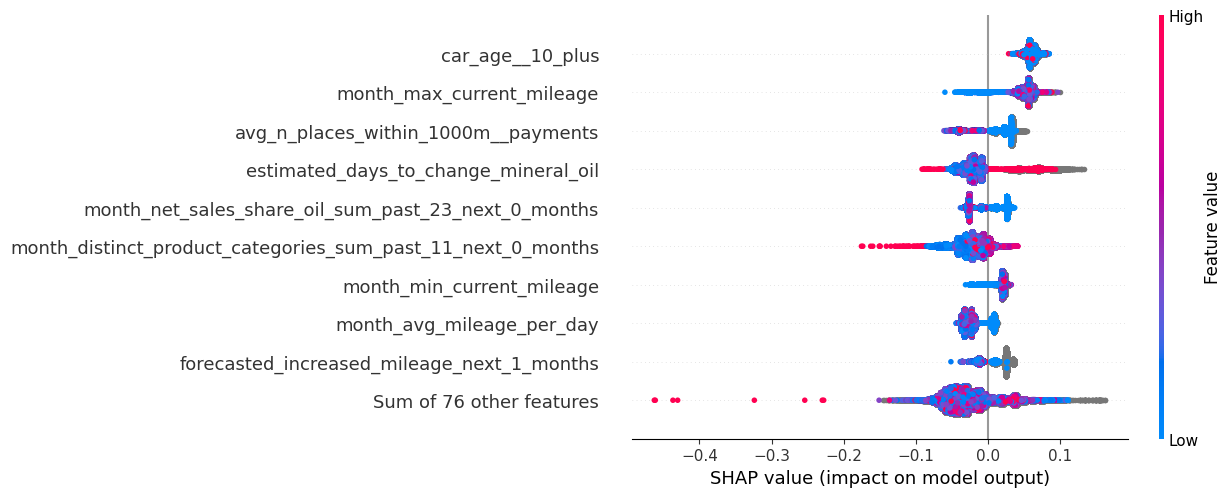

In [45]:
shap.plots.beeswarm(shap_values)

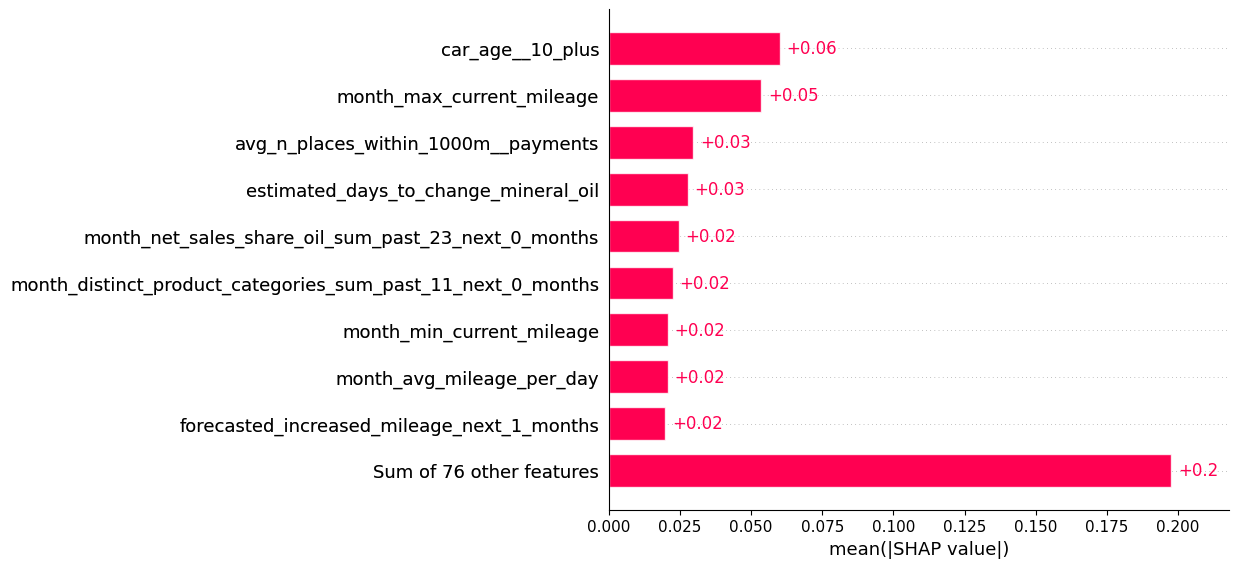

In [46]:
shap.plots.bar(shap_values)


In [47]:
shap_values[..., 1]

.values =
array([0., 0., 0., ..., 0., 0., 0.])

.base_values =
array([0.48490011, 0.48490011, 0.48490011, ..., 0.48490011, 0.48490011,
       0.48490011])

.data =
array([nan, nan, nan, ...,  1., nan,  1.])

In [48]:
shap_df = pd.DataFrame(shap_values.values, columns=features)

In [49]:
positive_feature_importance = (
    shap_df[shap_df > 0]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'index':'feature',0:'weight'})
    .head(10)
)

negative_feature_importance = (
    shap_df[shap_df < 0]
    .mean()
    .sort_values(ascending=True)
    .reset_index()
    .rename(columns={'index':'feature',0:'weight'})
    .head(10)
)

In [50]:
print(positive_feature_importance.to_string())

                                                       feature    weight
0                         estimated_days_to_change_mineral_oil  0.061840
1                                             car_age__10_plus  0.059989
2                                    month_max_current_mileage  0.054418
3                          avg_n_places_within_1000m__payments  0.028346
4          month_net_sales_share_oil_sum_past_23_next_0_months  0.024648
5                   forecasted_increased_mileage_next_1_months  0.023074
6                                    month_min_current_mileage  0.020870
7                                                      car_age  0.019181
8  month_net_sales_share_oil_filter_mean_past_23_next_0_months  0.017820
9                   month_total_cost_sum_past_23_next_0_months  0.016947


In [51]:
print(negative_feature_importance.to_string())

                                                       feature    weight
0                          avg_n_places_within_1000m__payments -0.035689
1                                     last_trx_current_mileage -0.029665
2                                    month_avg_mileage_per_day -0.025669
3          month_net_sales_share_oil_sum_past_23_next_0_months -0.024561
4  month_distinct_product_categories_sum_past_11_next_0_months -0.024391
5                         estimated_days_to_change_mineral_oil -0.023045
6        month_distinct_transactions_sum_past_11_next_0_months -0.015305
7                                    month_min_current_mileage -0.014719
8                                    month_max_current_mileage -0.014504
9         total_transactions_week_3_mean_past_23_next_0_months -0.013975


In [52]:
feature_importance = (
    shap_df
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'index':'feature',0:'weight'})
    .head(10)
)

print(feature_importance.to_string())

                                                       feature    weight
0                                             car_age__10_plus  0.059989
1                                    month_max_current_mileage  0.053039
2                                    month_min_current_mileage  0.020551
3                          avg_n_places_within_1000m__payments  0.016805
4                                                      car_age  0.015619
5                   forecasted_increased_mileage_next_1_months  0.012747
6  month_net_sales_share_air_filter_mean_past_23_next_0_months  0.011866
7     total_transactions_at_weekend_mean_past_23_next_0_months  0.009811
8         month_total_qty_discounts_mean_past_23_next_0_months  0.003645
9         total_transactions_week_3_mean_past_23_next_0_months  0.002980


In [ ]:
shap.plots.bar(shap_values.abs.max(0)) # test avg positive/negative importance

In [ ]:
shap.plots.waterfall(shap_values[0])


In [ ]:
shap.plots.scatter(shap_values[:, "car_age"], color=shap_values)